# 01: Temelji, podaci i parsiranje

Generički temelji zajednički za sve sveske: konstante, parsiranje `.dat` fajlova, učitavanje korpusa i oznaka, slike i `.pkl` artefakti. Reprezentacija, metrike i klasterovanje žive u svesci 02, pravila u svesci 03.


In [8]:
import os, sys, time, warnings
if os.path.exists("vocabs.txt"):
    ROOT = os.getcwd()
elif os.path.exists("../vocabs.txt"):
    ROOT = os.path.abspath("..")
else:
    raise FileNotFoundError("Nije pronadjen path")
os.chdir(ROOT); sys.path.insert(0, ROOT)
print("ROOT =", ROOT)
%matplotlib inline
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import issparse
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.cluster import (KMeans, BisectingKMeans,
                             AgglomerativeClustering, Birch, DBSCAN,
                             SpectralClustering)
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                             davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.manifold import TSNE


ROOT = C:\Users\Trile\PycharmProjects\PythonProject3\important!


## Konstante

In [2]:
K_MAIN = 20
K_FINE = 72
SEEDS = (42, 7, 2026)

CLASS_NAMES = ["programming", "style", "reference", "java", "web",
               "internet", "culture", "design", "education",
               "language", "books", "writing", "computer", "english",
               "politics", "history", "philosophy", "science",
               "religion", "grammar"]
N_CLASSES = len(CLASS_NAMES)

FIG_DIR = "figures"
RESULTS_DIR = "results"


## Logovanje, slike i .pkl artefakti

In [3]:
def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)



def show_fig(name):
    os.makedirs(FIG_DIR, exist_ok=True)
    plt.savefig(os.path.join(FIG_DIR, name), dpi=120,
                bbox_inches="tight")
    plt.show()



def save_pkl(name, payload):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    path = os.path.join(RESULTS_DIR, name)
    joblib.dump(payload, path)
    print(f"  [pkl] {path}")


def cached(name, compute):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    path = os.path.join(RESULTS_DIR, name)
    if os.path.exists(path):
        print(f"  [keš] {name} učitan (obriši za ponovni račun)")
        return joblib.load(path)
    value = compute()
    joblib.dump(value, path)
    print(f"  [keš] {name} izračunato i sačuvano")
    return value

## Parsiranje `.dat` fajlova


In [4]:
def load_vocab(path="vocabs.txt"):
    vocab = {}
    with open(path) as file:
        for line in file:
            word, index = line.rsplit(",", 1)
            vocab[int(index)] = word.strip()
    return vocab



def parse_flat_docs(path):
    documents = []
    with open(path) as file:
        for line in file:
            tokens = line.replace("<", "").replace(">", "").split()
            if not tokens:
                continue
            sentence_count = int(tokens[0]); cursor = 1
            document_words = []
            for _ in range(sentence_count):
                word_count = int(tokens[cursor]); cursor += 1
                document_words.extend(
                    int(word) for word in
                    tokens[cursor:cursor + word_count])
                cursor += word_count
            documents.append(document_words)
    return documents



def parse_sentences(path):
    documents = []
    with open(path) as file:
        for line in file:
            tokens = line.replace("<", "").replace(">", "").split()
            if not tokens:
                continue
            sentence_count = int(tokens[0]); cursor = 1; sents = []
            for _ in range(sentence_count):
                word_count = int(tokens[cursor]); cursor += 1
                sents.append([int(word) for word in
                              tokens[cursor:cursor + word_count]])
                cursor += word_count
            documents.append(sents)
    return documents


## 1. Učitavanje sirovih fajlova

In [5]:
vocab = load_vocab()
train_docs = parse_flat_docs("train-data.dat")
test_docs  = parse_flat_docs("test-data.dat")
train_sents = parse_sentences("train-data.dat")
test_sents  = parse_sentences("test-data.dat")

n_docs  = len(train_docs) + len(test_docs)
n_sents = sum(len(d) for d in train_sents) + sum(len(d) for d in test_sents)
n_words = sum(len(d) for d in train_docs) + sum(len(d) for d in test_docs)
print(f"dokumenata : {len(train_docs)} (train) + {len(test_docs)} (test) = {n_docs}")
print(f"rečenica   : {n_sents}")
print(f"tokena     : {n_words}")
print(f"rečnik     : {len(vocab)} stemovanih reči (Porter + stop-reči uklonjeni na izvoru)")
print(f"primer     : {' '.join(vocab.get(w, '?') for w in train_docs[0][:12])} ...")

dokumenata : 8251 (train) + 3983 (test) = 12234
rečenica   : 223288
tokena     : 1495228
rečnik     : 8520 stemovanih reči (Porter + stop-reči uklonjeni na izvoru)
primer     : rubi rail helper demo more info auto complet see new helper action ...


### Dužine: reči po dokumentu, rečenice po dokumentu, reči po rečenici

reči/dokument    : mean 122, median 118, max 270
rečenica/dokument: mean 18.3, median 18, max 31
reči/rečenica   : mean 6.7, median 7, max 10


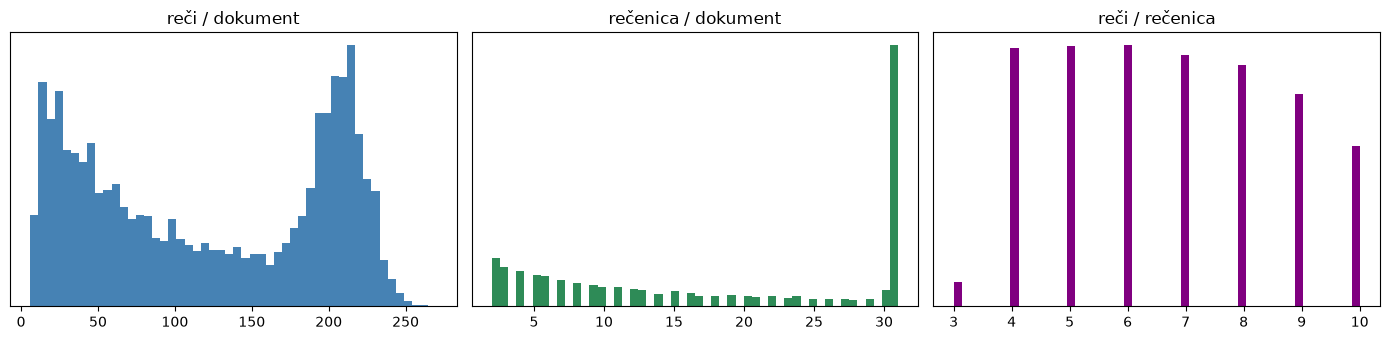

In [6]:
doc_words = np.array([len(d) for d in train_docs + test_docs])
doc_sents = np.array([len(d) for d in train_sents + test_sents])
sent_words = np.array([len(s) for doc in train_sents + test_sents for s in doc])
print(f"reči/dokument    : mean {doc_words.mean():.0f}, median {np.median(doc_words):.0f}, max {doc_words.max()}")
print(f"rečenica/dokument: mean {doc_sents.mean():.1f}, median {np.median(doc_sents):.0f}, max {doc_sents.max()}")
print(f"reči/rečenica   : mean {sent_words.mean():.1f}, median {np.median(sent_words):.0f}, max {sent_words.max()}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(np.clip(doc_words, 0, 1500), bins=50, color="steelblue"); axes[0].set_title("reči / dokument")
axes[1].hist(np.clip(doc_sents, 0, 150), bins=50, color="seagreen");   axes[1].set_title("rečenica / dokument")
axes[2].hist(np.clip(sent_words, 0, 80), bins=50, color="purple");     axes[2].set_title("reči / rečenica")
for ax in axes: ax.set_yticks([])
plt.tight_layout()
show_fig("corpus_lengths.png")

## 2. Oznake dokumenata i anotirane rečenice


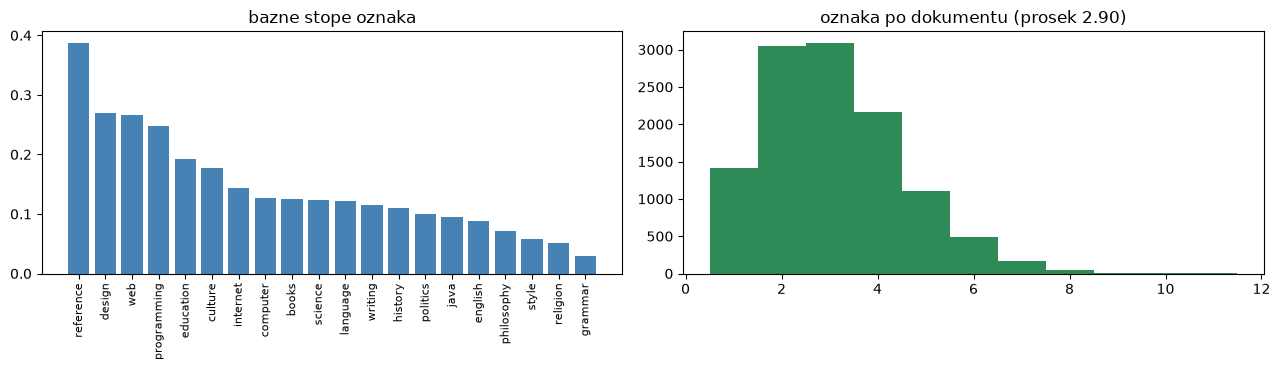

anotirane rečenice: 1468 | bez ijedne klase: 387
pravih oznaka po anotiranoj rečenici: 1.23 (nasleđenih bi bilo ~2.9)
  [0] see messag use non frame capabl web client
       prave oznake: programming
  [600] count follow file size approx
       prave oznake: (nijedna)
  [1200] leader congression progress show support
       prave oznake: politics


In [7]:
Y = np.vstack([
    pd.read_csv("train-label.dat", sep=" ", header=None).values,
    pd.read_csv("test-label.dat",  sep=" ", header=None).values,
]).astype(int)
rates = Y.mean(0)
order = np.argsort(rates)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(range(20), rates[order], color="steelblue")
axes[0].set_xticks(range(20))
axes[0].set_xticklabels([CLASS_NAMES[i] for i in order], rotation=90, fontsize=8)
axes[0].set_title("bazne stope oznaka")
axes[1].hist(Y.sum(1), bins=np.arange(0.5, 12.5), color="seagreen")
axes[1].set_title(f"oznaka po dokumentu (prosek {Y.sum(1).mean():.2f})")
plt.tight_layout()
show_fig("label_base_rates.png")

g_rows = []
with open("labeled_test_sentences.dat") as f:
    gold_lines = f.readlines()
for line in gold_lines:
    p = line.split()
    g_rows.append([int(x) for x in p[2:22]])
gY = np.array(g_rows)
print(f"anotirane rečenice: {len(gY)} | bez ijedne klase: {(gY.sum(1)==0).sum()}")
print(f"pravih oznaka po anotiranoj rečenici: {gY.sum(1).mean():.2f} (nasleđenih bi bilo ~2.9)")
for i in [0, 600, 1200]:
    parts = gold_lines[i].split()
    d, s = int(parts[0]), int(parts[1])
    labels = [CLASS_NAMES[j] for j in range(20) if gY[i, j]]
    print(f"  [{i}] {' '.join(vocab.get(w,'?') for w in test_sents[d][s])[:90]}")
    print(f"       prave oznake: {', '.join(labels) or '(nijedna)'}")